# Case: Piccolo Doppio (FLMS) — complete calibration-to-indices pipeline

**Authors:** L. Mihai (laura.mihai@inflpr.ro)

**Reference:** Werfeli, Mihai et al. (2026), *"Uncertainty propagation and
intercomparison of multi-sensor measurements of vegetation stress in
sub-optimal conditions."*

This notebook walks through the **complete** Piccolo Doppio processing
chain, from raw detector counts to five vegetation indices with propagated
uncertainty — every step, including the radiometric calibration chain
itself. It uses the real calibration and index functions (unchanged), and
runs end to end on one real example: the FLMS detector, Plot 103, 2025
Norway campaign.

A spectrometer's raw output is a digital count, not a physical quantity. To
turn it into something scientifically meaningful, that count has to be
traced back to a physical unit through an unbroken chain of comparisons
against reference standards. This notebook has **three calibration stages**,
each re-anchoring the calibration closer to the actual field conditions:

1. **Laboratory calibration** — the detector's raw response is related to a
   radiance/irradiance standard under controlled lab conditions.
2. **Laboratory validation (ValGEOS)** — the lab calibration is checked
   against an independent transfer standard, confirming it before it leaves
   the lab.
3. **Field calibration** — the validated calibration is re-anchored using a
   field validation measurement, accounting for whatever changed (transport,
   temperature, time elapsed) between the lab and the campaign.

After that: **field measurement** at 5 points → **reflectance** → **plot
mean** → **five vegetation indices** (NDVI, EVI, OSAVI, MTCI, PRI).

!!! note "Not just for this dataset"
    The same calibration-chain structure and code apply to any dual-fibre
    spectrometer built around Ocean Insight QE-series detectors (cosine
    diffuser for irradiance, collimator/bare fibre for radiance) — including
    **FLOX** and similar custom dual-optic setups. Point the loader at your
    own raw files, in the same format, and it runs unchanged.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import punpy

DATA_DIR = Path("../data/case-piccolo-plot103-full")
sensor = "FLMS"
plot_id = "103"
WL_MIN, WL_MAX = 400, 900   # FLMS detector's usable wavelength range
N_MC = 10000                 # punpy Monte Carlo sample size
k = 2                        # expansion factor for reporting (not used directly below)

prop = punpy.MCPropagation(N_MC, parallel_cores=1)

import matplotlib.pyplot as plt

def load(name):
    return np.loadtxt(DATA_DIR / f"{name}.txt")

def load2d(name):
    a = load(name)
    return a.reshape(-1, 1) if a.ndim == 1 else a

def col(x):
    return np.asarray(x, dtype=float).reshape(-1, 1)

def apply_IT(DN, IT):
    # Scale raw counts by integration time, so measurements taken with
    # different exposure settings become comparable.
    return np.asarray(DN, float) * float(IT)

def a1(x):
    return np.array([float(x)], dtype=float)

## The calibration and index formulas

These five functions are the real, unmodified calibration chain — the
actual measurement equations, not a simplified stand-in. Each takes a
measured signal and returns a calibrated quantity; `punpy` propagates
uncertainty through them exactly as written, the same way it propagates
uncertainty through the reflectance and index formulas later on.

- `CalibrationCoeffsNonlin` — from a lab standard, produces the lab
  calibration coefficient.
- `VALGEOSCalibrationNonlin` — applies that coefficient to the validation
  measurement, producing a validated reference value (ValGEOS).
- `FieldCalCoeffsNonlin` — from the ValGEOS reference, produces the
  campaign's field calibration coefficient.
- `FieldRadianceNonlin` — applies the field coefficient to an actual field
  measurement, producing calibrated radiance/irradiance.
- `Reflectance` — combines calibrated radiance and irradiance into
  reflectance, R = π·L/E.

In [2]:
def safe_divide(num, denom, eps=1e-12):
    num = np.asarray(num, dtype=float)
    denom = np.asarray(denom, dtype=float)
    return num / (denom + eps)

def CalibrationCoeffsNonlin(light, dark, STD, nonlinCorr):
    return safe_divide(STD, (light - dark) * nonlinCorr)

def VALGEOSCalibrationNonlin(CalCoeffs_nonlin, light_val, dark_val, nonlinCorr_val):
    return CalCoeffs_nonlin * ((light_val - dark_val) * nonlinCorr_val)

def FieldCalCoeffsNonlin(VALGEOSCoeffs, light_valF, dark_valF, nonlinCorr_valF):
    return safe_divide(VALGEOSCoeffs, ((light_valF - dark_valF) * nonlinCorr_valF))

def FieldRadianceNonlin(CalCoeffs_valF, light_F, dark_F, nonlinCorr_F):
    return CalCoeffs_valF * (light_F - dark_F) * nonlinCorr_F

def Reflectance(L_field, E_field):
    return np.pi * safe_divide(L_field, E_field)

# The five vegetation indices used throughout this training material
def PRI_fun(R570, R531): return safe_divide((R570 - R531), (R570 + R531))
def NDVI_fun(R780, R670): return safe_divide((R780 - R670), (R780 + R670))
def EVI_fun(R480, R670, R780): return 2.5 * safe_divide((R780 - R670), (R780 + 6*R670 - 7.5*R480 + 1.0))
def MTCI_fun(R681, R709, R754): return safe_divide((R754 - R709), (R709 - R681))
def OSAVI_fun(R670, R780): return 1.16 * safe_divide((R780 - R670), (R780 + R670 + 0.16))

def corr_almost_fully_correlated(n, rho=0.999999):
    # Correlation matrix for quantities that share the same systematic
    # error source (e.g. two reflectance bands derived from the same
    # calibration chain) — nearly-1 off-diagonal, not exactly 1, for
    # numerical stability.
    I = np.eye(n, dtype=float)
    J = np.ones((n, n), dtype=float)
    return rho * J + (1.0 - rho) * I

corr2 = corr_almost_fully_correlated(2)
corr3 = corr_almost_fully_correlated(3)

## Stage 1 — Laboratory calibration

The detector's raw counts (`light`) minus its dark-current baseline
(`dark`), corrected for the detector's own non-linearity, are related to a
known laboratory radiance/irradiance standard. This produces a **calibration
coefficient per wavelength** — the number that converts a raw count into a
physically meaningful unit, still only valid under lab conditions at this
point.

Every calibrated quantity from here on carries **two separate uncertainty
components**: a **random** one (from repeat-measurement noise, propagated
with `propagate_random`) and a **systematic** one (from the reference
standard's own calibration uncertainty and the non-linearity correction,
propagated with `propagate_systematic`) — kept separate throughout, since a
random component shrinks when you average repeated measurements and a
systematic one does not.

Stage 1 (lab calibration) done.


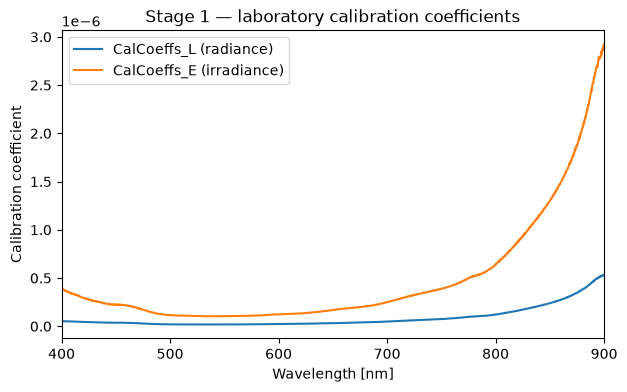

In [3]:
L0 = load2d(f"{sensor}_L_lg_ITCorr_LabCal2023")            # raw radiance counts (light)
dark_L0 = load2d(f"{sensor}_L_dk_ITCorr_LabCal2023")        # raw radiance counts (dark)
IT_L0 = float(load(f"{sensor}_L_IT_Lab2023"))               # integration time used
E0 = load2d(f"{sensor}_E_lg_ITCorr_LabCal2023")
dark_E0 = load2d(f"{sensor}_E_dk_ITCorr_LabCal2023")
IT_E0 = float(load(f"{sensor}_E_IT_Lab2023"))

Radiance_SI = col(load(f"RadianceStd_{sensor}_Lab2023"))       # lab radiance standard
Irradiance_SI = col(load(f"IrradianceStd_{sensor}_Lab2023"))   # lab irradiance standard
C_nonlin = load(f"coeffsNonlin_{sensor}_Lab2023").reshape(-1)  # detector non-linearity polynomial

L0_m = np.mean(L0, axis=1, keepdims=True)
dark_L0_m = np.mean(dark_L0, axis=1, keepdims=True)
E0_m = np.mean(E0, axis=1, keepdims=True)
dark_E0_m = np.mean(dark_E0, axis=1, keepdims=True)

# Integration-time-scaled, dark-corrected signal feeds the non-linearity correction
DataL0_Rad = apply_IT(L0, IT_L0); Datadark_Rad = apply_IT(dark_L0, IT_L0)
DataE0_Irrad = apply_IT(E0, IT_E0); Datadark_Irrad = apply_IT(dark_E0, IT_E0)
DN_DC_Rad = (DataL0_Rad - Datadark_Rad).mean(axis=1, keepdims=True)
DN_DC_Irrad = (DataE0_Irrad - Datadark_Irrad).mean(axis=1, keepdims=True)
CorNonlin_L0 = col(1.0 / np.polyval(C_nonlin, DN_DC_Rad[:, 0]))
CorNonlin_E0 = col(1.0 / np.polyval(C_nonlin, DN_DC_Irrad[:, 0]))

CalCoeffs_L_nonlin = CalibrationCoeffsNonlin(L0_m, dark_L0_m, Radiance_SI, CorNonlin_L0)
CalCoeffs_E_nonlin = CalibrationCoeffsNonlin(E0_m, dark_E0_m, Irradiance_SI, CorNonlin_E0)

# Random uncertainty: standard error across the repeat lab scans
L0_ur = np.std(L0, axis=1, ddof=1, keepdims=True) / np.sqrt(L0.shape[1])
dark_L0_ur = np.std(dark_L0, axis=1, ddof=1, keepdims=True) / np.sqrt(dark_L0.shape[1])
E0_ur = np.std(E0, axis=1, ddof=1, keepdims=True) / np.sqrt(E0.shape[1])
dark_E0_ur = np.std(dark_E0, axis=1, ddof=1, keepdims=True) / np.sqrt(dark_E0.shape[1])

CalCoeffs_L_ur = prop.propagate_random(CalibrationCoeffsNonlin,
    [L0_m, dark_L0_m, Radiance_SI, CorNonlin_L0],
    [L0_ur, dark_L0_ur, np.zeros_like(Radiance_SI), np.zeros_like(CorNonlin_L0)])
CalCoeffs_E_ur = prop.propagate_random(CalibrationCoeffsNonlin,
    [E0_m, dark_E0_m, Irradiance_SI, CorNonlin_E0],
    [E0_ur, dark_E0_ur, np.zeros_like(Irradiance_SI), np.zeros_like(CorNonlin_E0)])

# Systematic uncertainty: the lab standard's own calibration uncertainty + non-linearity residual
Radiance_us_abs = col(load(f"u_{sensor}_L_std_abs_Lab2023"))
Irradiance_us_abs = col(load(f"u_{sensor}_E_std_abs_Lab2023"))
CalCoeffs_nonlin_us_rel = col(load(f"u_{sensor}_nonlin_residual_Lab2023"))
CalCoeffsL0_nonlin_us_abs = CorNonlin_L0 * (CalCoeffs_nonlin_us_rel / 100.0)
CalCoeffsE0_nonlin_us_abs = CorNonlin_E0 * (CalCoeffs_nonlin_us_rel / 100.0)

CalCoeffs_L_us = prop.propagate_systematic(CalibrationCoeffsNonlin,
    [L0_m, dark_L0_m, Radiance_SI, CorNonlin_L0],
    [np.zeros_like(L0_m), np.zeros_like(dark_L0_m), Radiance_us_abs, CalCoeffsL0_nonlin_us_abs])
CalCoeffs_E_us = prop.propagate_systematic(CalibrationCoeffsNonlin,
    [E0_m, dark_E0_m, Irradiance_SI, CorNonlin_E0],
    [np.zeros_like(E0_m), np.zeros_like(dark_E0_m), Irradiance_us_abs, CalCoeffsE0_nonlin_us_abs])

print("Stage 1 (lab calibration) done.")

wvlL_lab = load(f"{sensor}_L_Wavelength_Lab2023")
wvlE_lab = load(f"{sensor}_E_Wavelength_Lab2023")
mL_lab = (wvlL_lab >= WL_MIN) & (wvlL_lab <= WL_MAX)
mE_lab = (wvlE_lab >= WL_MIN) & (wvlE_lab <= WL_MAX)

plt.figure(figsize=(7, 4))
plt.plot(wvlL_lab[mL_lab], CalCoeffs_L_nonlin.ravel()[mL_lab], label='CalCoeffs_L (radiance)')
plt.plot(wvlE_lab[mE_lab], CalCoeffs_E_nonlin.ravel()[mE_lab], label='CalCoeffs_E (irradiance)')
plt.xlim(WL_MIN, WL_MAX)
plt.xlabel('Wavelength [nm]'); plt.ylabel('Calibration coefficient')
plt.legend(); plt.title('Stage 1 — laboratory calibration coefficients')
plt.show()

## Stage 2 — Laboratory validation (ValGEOS)

The lab calibration coefficient is applied to a second, independent
measurement — against ValGEOS, a transfer standard — confirming the
calibration is trustworthy before it ever leaves the lab. Both random and
systematic uncertainty carry forward from Stage 1, combined with this
stage's own measurement uncertainty.

Stage 2 (lab validation / ValGEOS) done.


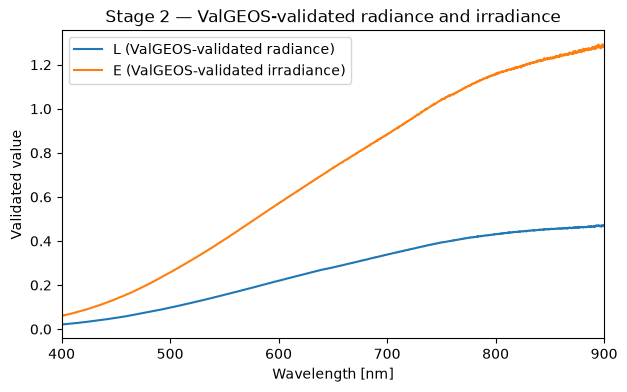

In [4]:
L0_val = load2d(f"{sensor}_L_lg_ITCorr_LabVal2023")
dark_L0_val = load2d(f"{sensor}_L_dk_ITCorr_LabVal2023")
E0_val = load2d(f"{sensor}_E_lg_ITCorr_LabVal2023")
dark_E0_val = load2d(f"{sensor}_E_dk_ITCorr_LabVal2023")

L0_m_val = np.mean(L0_val, axis=1, keepdims=True)
dark_L0_m_val = np.mean(dark_L0_val, axis=1, keepdims=True)
E0_m_val = np.mean(E0_val, axis=1, keepdims=True)
dark_E0_m_val = np.mean(dark_E0_val, axis=1, keepdims=True)

DataL0_Rad_val = apply_IT(L0_val, float(load(f"{sensor}_L_IT_ValLab2023")))
Datadark_Rad_val = apply_IT(dark_L0_val, float(load(f"{sensor}_L_IT_ValLab2023")))
DataE0_Irrad_val = apply_IT(E0_val, float(load(f"{sensor}_E_IT_ValLab2023")))
Datadark_Irrad_val = apply_IT(dark_E0_val, float(load(f"{sensor}_E_IT_ValLab2023")))
DN_DC_Rad_val = (DataL0_Rad_val - Datadark_Rad_val).mean(axis=1, keepdims=True)
DN_DC_Irrad_val = (DataE0_Irrad_val - Datadark_Irrad_val).mean(axis=1, keepdims=True)
CorNonlin_L0_val = col(1.0 / np.polyval(C_nonlin, DN_DC_Rad_val[:, 0]))
CorNonlin_E0_val = col(1.0 / np.polyval(C_nonlin, DN_DC_Irrad_val[:, 0]))

Lvalgeos_nonlin = VALGEOSCalibrationNonlin(CalCoeffs_L_nonlin, L0_m_val, dark_L0_m_val, CorNonlin_L0_val)
Evalgeos_nonlin = VALGEOSCalibrationNonlin(CalCoeffs_E_nonlin, E0_m_val, dark_E0_m_val, CorNonlin_E0_val)

L0_ur_val = np.std(L0_val, axis=1, ddof=1, keepdims=True) / np.sqrt(L0_val.shape[1])
dark_L0_ur_val = np.std(dark_L0_val, axis=1, ddof=1, keepdims=True) / np.sqrt(dark_L0_val.shape[1])
E0_ur_val = np.std(E0_val, axis=1, ddof=1, keepdims=True) / np.sqrt(E0_val.shape[1])
dark_E0_ur_val = np.std(dark_E0_val, axis=1, ddof=1, keepdims=True) / np.sqrt(dark_E0_val.shape[1])

Lvalgeos_ur = prop.propagate_random(VALGEOSCalibrationNonlin,
    [CalCoeffs_L_nonlin, L0_m_val, dark_L0_m_val, CorNonlin_L0_val],
    [CalCoeffs_L_ur, L0_ur_val, dark_L0_ur_val, np.zeros_like(CorNonlin_L0_val)])
Evalgeos_ur = prop.propagate_random(VALGEOSCalibrationNonlin,
    [CalCoeffs_E_nonlin, E0_m_val, dark_E0_m_val, CorNonlin_E0_val],
    [CalCoeffs_E_ur, E0_ur_val, dark_E0_ur_val, np.zeros_like(CorNonlin_E0_val)])

CalCoeffsL0_val_nonlin_us_abs = CorNonlin_L0_val * (CalCoeffs_nonlin_us_rel / 100.0)
CalCoeffsE0_val_nonlin_us_abs = CorNonlin_E0_val * (CalCoeffs_nonlin_us_rel / 100.0)

Lvalgeos_us = prop.propagate_systematic(VALGEOSCalibrationNonlin,
    [CalCoeffs_L_nonlin, L0_m_val, dark_L0_m_val, CorNonlin_L0_val],
    [CalCoeffs_L_us, np.zeros_like(L0_m_val), np.zeros_like(dark_L0_m_val), CalCoeffsL0_val_nonlin_us_abs])
Evalgeos_us = prop.propagate_systematic(VALGEOSCalibrationNonlin,
    [CalCoeffs_E_nonlin, E0_m_val, dark_E0_m_val, CorNonlin_E0_val],
    [CalCoeffs_E_us, np.zeros_like(E0_m_val), np.zeros_like(dark_E0_m_val), CalCoeffsE0_val_nonlin_us_abs])

print("Stage 2 (lab validation / ValGEOS) done.")

wvlL_val = load(f"{sensor}_L_Wavelength_ValLab2023")
wvlE_val = load(f"{sensor}_E_Wavelength_ValLab2023")
mL_val = (wvlL_val >= WL_MIN) & (wvlL_val <= WL_MAX)
mE_val = (wvlE_val >= WL_MIN) & (wvlE_val <= WL_MAX)

plt.figure(figsize=(7, 4))
plt.plot(wvlL_val[mL_val], Lvalgeos_nonlin.ravel()[mL_val], label='L (ValGEOS-validated radiance)')
plt.plot(wvlE_val[mE_val], Evalgeos_nonlin.ravel()[mE_val], label='E (ValGEOS-validated irradiance)')
plt.xlim(WL_MIN, WL_MAX)
plt.xlabel('Wavelength [nm]'); plt.ylabel('Validated value')
plt.legend(); plt.title('Stage 2 — ValGEOS-validated radiance and irradiance')
plt.show()

## Stage 3 — Field calibration coefficients

The validated ValGEOS reference is now re-measured **at the field
campaign**, re-anchoring the calibration to account for anything that
changed since the lab (transport, temperature, time elapsed). This produces
the coefficient actually used to calibrate the campaign's field
measurements.

Stage 3 (field calibration coefficients) done.


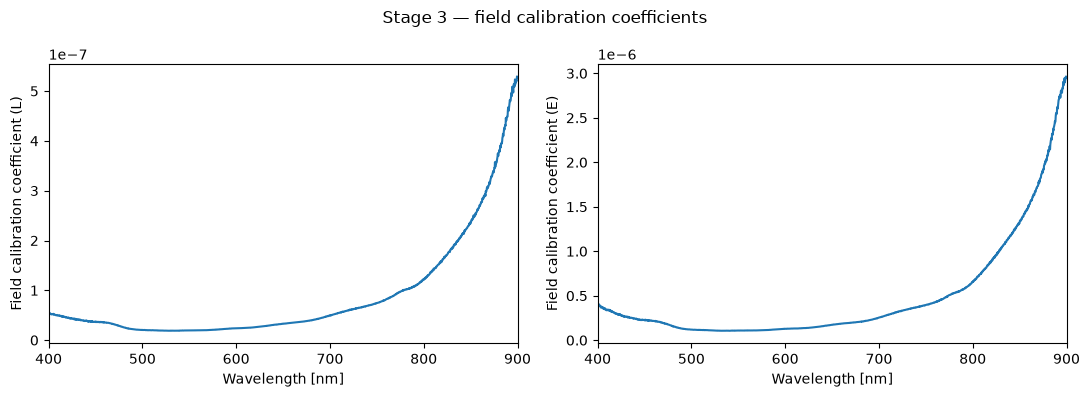

In [5]:
Wvl_L_val2025 = load(f"{sensor}_L_Wavelength_Val2025").reshape(-1, 1)
Wvl_E_val2025 = load(f"{sensor}_E_Wavelength_Val2025").reshape(-1, 1)
wvlL = Wvl_L_val2025.ravel(); wvlE = Wvl_E_val2025.ravel()
mask_wvlL = (wvlL >= WL_MIN) & (wvlL <= WL_MAX)
mask_wvlE = (wvlE >= WL_MIN) & (wvlE <= WL_MAX)

L0_valF = load2d(f"{sensor}_L_lg_ITCorr_FieldVal2025")
dark_L0_valF = load2d(f"{sensor}_L_dk_ITCorr_FieldVal2025")
E0_valF = load2d(f"{sensor}_E_lg_ITCorr_FieldVal2025")
dark_E0_valF = load2d(f"{sensor}_E_dk_ITCorr_FieldVal2025")

L0_m_valF = np.mean(L0_valF, axis=1, keepdims=True)
dark_L0_m_valF = np.mean(dark_L0_valF, axis=1, keepdims=True)
E0_m_valF = np.mean(E0_valF, axis=1, keepdims=True)
dark_E0_m_valF = np.mean(dark_E0_valF, axis=1, keepdims=True)

DataL0_Rad_valF = apply_IT(L0_valF, float(load(f"{sensor}_L_IT_Val2025")))
Datadark_Rad_valF = apply_IT(dark_L0_valF, float(load(f"{sensor}_L_IT_Val2025")))
DataE0_Irrad_valF = apply_IT(E0_valF, float(load(f"{sensor}_E_IT_Val2025")))
Datadark_Irrad_valF = apply_IT(dark_E0_valF, float(load(f"{sensor}_E_IT_Val2025")))
DN_DC_Rad_valF = (DataL0_Rad_valF - Datadark_Rad_valF).mean(axis=1, keepdims=True)
DN_DC_Irrad_valF = (DataE0_Irrad_valF - Datadark_Irrad_valF).mean(axis=1, keepdims=True)
CorNonlin_L0_valF = col(1.0 / np.polyval(C_nonlin, DN_DC_Rad_valF[:, 0]))
CorNonlin_E0_valF = col(1.0 / np.polyval(C_nonlin, DN_DC_Irrad_valF[:, 0]))
CalCoeffsL0_valF_nonlin_us_abs = CorNonlin_L0_valF * (CalCoeffs_nonlin_us_rel / 100.0)
CalCoeffsE0_valF_nonlin_us_abs = CorNonlin_E0_valF * (CalCoeffs_nonlin_us_rel / 100.0)

CalCoeffsL_valF_nonlin = FieldCalCoeffsNonlin(Lvalgeos_nonlin, L0_m_valF, dark_L0_m_valF, CorNonlin_L0_valF)
CalCoeffsE_valF_nonlin = FieldCalCoeffsNonlin(Evalgeos_nonlin, E0_m_valF, dark_E0_m_valF, CorNonlin_E0_valF)

L0_ur_valF = np.std(L0_valF, axis=1, ddof=1, keepdims=True) / np.sqrt(L0_valF.shape[1])
dark_L0_ur_valF = np.std(dark_L0_valF, axis=1, ddof=1, keepdims=True) / np.sqrt(dark_L0_valF.shape[1])
E0_ur_valF = np.std(E0_valF, axis=1, ddof=1, keepdims=True) / np.sqrt(E0_valF.shape[1])
dark_E0_ur_valF = np.std(dark_E0_valF, axis=1, ddof=1, keepdims=True) / np.sqrt(dark_E0_valF.shape[1])

CalCoeffsL_valF_ur = prop.propagate_random(FieldCalCoeffsNonlin,
    [Lvalgeos_nonlin, L0_m_valF, dark_L0_m_valF, CorNonlin_L0_valF],
    [Lvalgeos_ur, L0_ur_valF, dark_L0_ur_valF, np.zeros_like(CorNonlin_L0_valF)])
CalCoeffsE_valF_ur = prop.propagate_random(FieldCalCoeffsNonlin,
    [Evalgeos_nonlin, E0_m_valF, dark_E0_m_valF, CorNonlin_E0_valF],
    [Evalgeos_ur, E0_ur_valF, dark_E0_ur_valF, np.zeros_like(CorNonlin_E0_valF)])
CalCoeffsL_valF_us = prop.propagate_systematic(FieldCalCoeffsNonlin,
    [Lvalgeos_nonlin, L0_m_valF, dark_L0_m_valF, CorNonlin_L0_valF],
    [Lvalgeos_us, np.zeros_like(L0_m_valF), np.zeros_like(dark_L0_m_valF), CalCoeffsL0_valF_nonlin_us_abs])
CalCoeffsE_valF_us = prop.propagate_systematic(FieldCalCoeffsNonlin,
    [Evalgeos_nonlin, E0_m_valF, dark_E0_m_valF, CorNonlin_E0_valF],
    [Evalgeos_us, np.zeros_like(E0_m_valF), np.zeros_like(dark_E0_m_valF), CalCoeffsE0_valF_nonlin_us_abs])

print("Stage 3 (field calibration coefficients) done.")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(wvlL[mask_wvlL], CalCoeffsL_valF_nonlin.ravel()[mask_wvlL])
axes[0].set_xlim(WL_MIN, WL_MAX)
axes[0].set_xlabel('Wavelength [nm]'); axes[0].set_ylabel('Field calibration coefficient (L)')
axes[1].plot(wvlE[mask_wvlE], CalCoeffsE_valF_nonlin.ravel()[mask_wvlE])
axes[1].set_xlim(WL_MIN, WL_MAX)
axes[1].set_xlabel('Wavelength [nm]'); axes[1].set_ylabel('Field calibration coefficient (E)')
fig.suptitle('Stage 3 — field calibration coefficients')
plt.tight_layout(); plt.show()

## Stage 4 — Field measurements, per point

For each of the 5 measurement points in Plot 103, the field calibration
coefficient is applied to that point's own raw signal, producing calibrated
radiance (L) and irradiance (E). Reflectance follows directly, R = π·L/E.

One correction is added here that is public (it is in the paper's Results
section, not part of the confidential calibration methodology): the
irradiance sensor's cosine receptor deviates from the ideal cosine law, and
this is added as an *additional* systematic uncertainty on irradiance,
sized per plot by solar zenith angle (Plot 103 uses the 9.94% group).

Point 103p1: calibrated, reflectance computed.


Point 103p2: calibrated, reflectance computed.


Point 103p3: calibrated, reflectance computed.


Point 103p4: calibrated, reflectance computed.


Point 103p5: calibrated, reflectance computed.


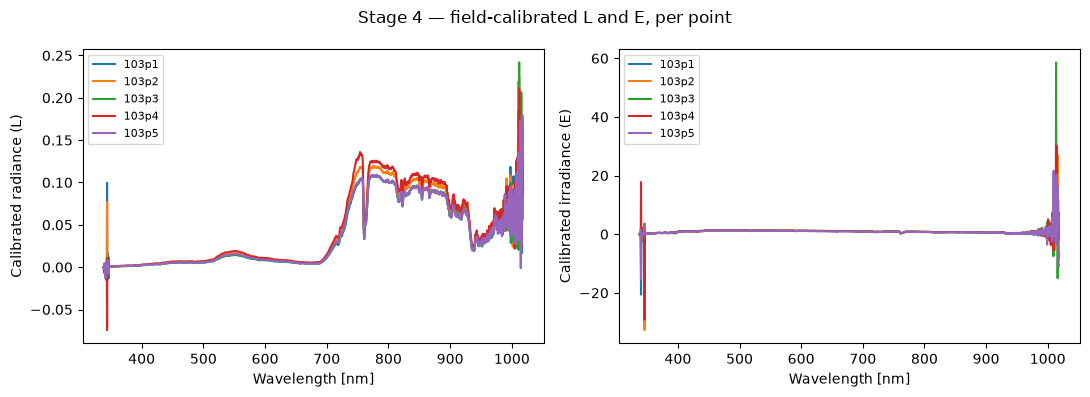

In [6]:
def cosine_u_abs_for_E(E_nonlin):
    # 9.94% relative uncertainty — the group Plot 103 belongs to (paper Results section)
    return 0.0994 * np.asarray(E_nonlin, float)

point_keys = [f"{plot_id}p{i}" for i in range(1, 6)]
L_F_nonlin, E_F_nonlin, R_F_nonlin = {}, {}, {}
L_F_ur, L_F_us, E_F_ur, E_F_us, R_F_ur, R_F_us = {}, {}, {}, {}, {}, {}

for pk in point_keys:
    L0_F = load2d(f"{sensor}_L_lg_ITCorr_Field2025_{pk}")
    dark_L0_F = load2d(f"{sensor}_L_dk_ITCorr_Field2025_{pk}")
    IT_L0_F = float(load(f"{sensor}_L_IT_Field2025_{pk}"))
    E0_F = load2d(f"{sensor}_E_lg_ITCorr_Field2025_{pk}")
    dark_E0_F = load2d(f"{sensor}_E_dk_ITCorr_Field2025_{pk}")
    IT_E0_F = float(load(f"{sensor}_E_IT_Field2025_{pk}"))

    DataL0_Rad = apply_IT(L0_F, IT_L0_F); Datadark_Rad = apply_IT(dark_L0_F, IT_L0_F)
    DataE0_Irrad = apply_IT(E0_F, IT_E0_F); Datadark_Irrad = apply_IT(dark_E0_F, IT_E0_F)
    L0_m_F = np.mean(L0_F, axis=1, keepdims=True); dark_L0_m_F = np.mean(dark_L0_F, axis=1, keepdims=True)
    E0_m_F = np.mean(E0_F, axis=1, keepdims=True); dark_E0_m_F = np.mean(dark_E0_F, axis=1, keepdims=True)
    DN_DC_Rad = (DataL0_Rad - Datadark_Rad).mean(axis=1, keepdims=True)
    DN_DC_Irrad = (DataE0_Irrad - Datadark_Irrad).mean(axis=1, keepdims=True)
    CorNonlin_L0_F = col(1.0 / np.polyval(C_nonlin, DN_DC_Rad[:, 0]))
    CorNonlin_E0_F = col(1.0 / np.polyval(C_nonlin, DN_DC_Irrad[:, 0]))
    CorNonlin_L0_F_us_abs = CorNonlin_L0_F * (CalCoeffs_nonlin_us_rel / 100.0)
    CorNonlin_E0_F_us_abs = CorNonlin_E0_F * (CalCoeffs_nonlin_us_rel / 100.0)

    L_nonlin = FieldRadianceNonlin(CalCoeffsL_valF_nonlin, L0_m_F, dark_L0_m_F, CorNonlin_L0_F)
    E_nonlin = FieldRadianceNonlin(CalCoeffsE_valF_nonlin, E0_m_F, dark_E0_m_F, CorNonlin_E0_F)

    L0_ur_F = np.std(L0_F, axis=1, ddof=1, keepdims=True) / np.sqrt(L0_F.shape[1])
    dark_L0_ur_F = np.std(dark_L0_F, axis=1, ddof=1, keepdims=True) / np.sqrt(dark_L0_F.shape[1])
    E0_ur_F = np.std(E0_F, axis=1, ddof=1, keepdims=True) / np.sqrt(E0_F.shape[1])
    dark_E0_ur_F = np.std(dark_E0_F, axis=1, ddof=1, keepdims=True) / np.sqrt(dark_E0_F.shape[1])

    L_ur = prop.propagate_random(FieldRadianceNonlin,
        [CalCoeffsL_valF_nonlin, L0_m_F, dark_L0_m_F, CorNonlin_L0_F],
        [CalCoeffsL_valF_ur, L0_ur_F, dark_L0_ur_F, np.zeros_like(CorNonlin_L0_F)])
    E_ur = prop.propagate_random(FieldRadianceNonlin,
        [CalCoeffsE_valF_nonlin, E0_m_F, dark_E0_m_F, CorNonlin_E0_F],
        [CalCoeffsE_valF_ur, E0_ur_F, dark_E0_ur_F, np.zeros_like(CorNonlin_E0_F)])
    L_us = prop.propagate_systematic(FieldRadianceNonlin,
        [CalCoeffsL_valF_nonlin, L0_m_F, dark_L0_m_F, CorNonlin_L0_F],
        [CalCoeffsL_valF_us, np.zeros_like(L0_m_F), np.zeros_like(dark_L0_m_F), CorNonlin_L0_F_us_abs])
    E_us = prop.propagate_systematic(FieldRadianceNonlin,
        [CalCoeffsE_valF_nonlin, E0_m_F, dark_E0_m_F, CorNonlin_E0_F],
        [CalCoeffsE_valF_us, np.zeros_like(E0_m_F), np.zeros_like(dark_E0_m_F), CorNonlin_E0_F_us_abs])

    # add the cosine-response systematic component onto E (rectangular distribution -> /sqrt(3))
    uE_cos_abs = cosine_u_abs_for_E(E_nonlin)
    E_us = np.sqrt(np.asarray(E_us, float)**2 + (uE_cos_abs / np.sqrt(3))**2)

    R_nonlin = Reflectance(L_nonlin, E_nonlin)
    R_ur = prop.propagate_random(Reflectance, [L_nonlin, E_nonlin], [L_ur, E_ur])
    R_us = prop.propagate_systematic(Reflectance, [L_nonlin, E_nonlin], [L_us, E_us])

    L_F_nonlin[pk] = L_nonlin; E_F_nonlin[pk] = E_nonlin; R_F_nonlin[pk] = R_nonlin
    L_F_ur[pk] = L_ur; L_F_us[pk] = L_us; E_F_ur[pk] = E_ur; E_F_us[pk] = E_us
    R_F_ur[pk] = R_ur; R_F_us[pk] = R_us
    print(f"Point {pk}: calibrated, reflectance computed.")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for pk in point_keys:
    axes[0].plot(wvlL, np.asarray(L_F_nonlin[pk]).ravel(), label=pk)
    axes[1].plot(wvlE, np.asarray(E_F_nonlin[pk]).ravel(), label=pk)
axes[0].set_xlabel('Wavelength [nm]'); axes[0].set_ylabel('Calibrated radiance (L)')
axes[1].set_xlabel('Wavelength [nm]'); axes[1].set_ylabel('Calibrated irradiance (E)')
axes[0].legend(fontsize=8); axes[1].legend(fontsize=8)
fig.suptitle('Stage 4 — field-calibrated L and E, per point')
plt.tight_layout(); plt.show()

## Stage 4b — Plot-level mean over the 5 points

Averaging 5 points does two things at once: it shrinks the random
component (more points → less random noise), while adding the
point-to-point spread back in as an extra random term — this is what turns
"5 repeated measurements" into a genuine field-heterogeneity contribution.
The systematic component is *not* reduced by averaging, since it affects
every point the same way — only its mean carries forward.

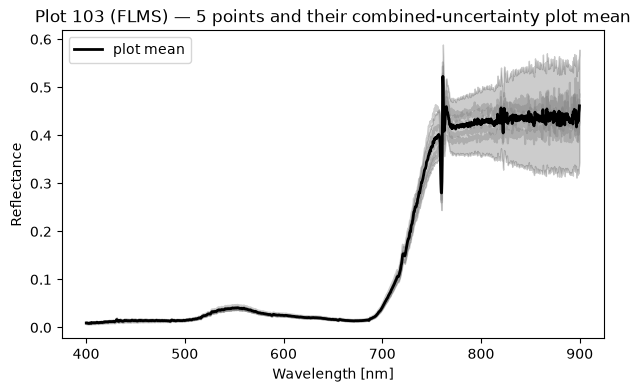

In [7]:
def propagate_plot_mean_with_components_fast(vals_list, ur_list, us_list, add_variability=True, ddof=1):
    V = np.stack([np.asarray(v, float).reshape(-1) for v in vals_list], axis=1)
    UR = np.stack([np.asarray(u, float).reshape(-1) for u in ur_list], axis=1)
    US = np.stack([np.asarray(u, float).reshape(-1) for u in us_list], axis=1)
    Np = V.shape[1]
    mean = np.mean(V, axis=1)
    u_r = np.sqrt(np.sum(UR**2, axis=1)) / Np
    if add_variability:
        u_var = np.std(V, axis=1, ddof=ddof) / np.sqrt(Np)   # point-to-point spread, added as extra randomness
        u_r = np.sqrt(u_r**2 + u_var**2)
    u_s = np.mean(US, axis=1)
    u_c = np.sqrt(u_r**2 + u_s**2)
    return mean.reshape(-1, 1), u_r.reshape(-1, 1), u_s.reshape(-1, 1), u_c.reshape(-1, 1)


R_vals = [R_F_nonlin[pk] for pk in point_keys]
R_urs = [R_F_ur[pk] for pk in point_keys]
R_uss = [R_F_us[pk] for pk in point_keys]
R_mean, R_u_r_mean, R_u_s_mean, R_u_c_mean = propagate_plot_mean_with_components_fast(R_vals, R_urs, R_uss)

Rm = np.asarray(R_mean).ravel()
ucRm = np.asarray(R_u_c_mean).ravel()
mR = (Rm > 1e-12) & mask_wvlL

import matplotlib.pyplot as plt
plt.figure(figsize=(7, 4))
for pk in point_keys:
    plt.plot(wvlL[mR], np.asarray(R_F_nonlin[pk]).ravel()[mR], color='grey', alpha=0.4)
plt.plot(wvlL[mR], Rm[mR], color='k', linewidth=2, label='plot mean')
plt.fill_between(wvlL[mR], Rm[mR] - ucRm[mR], Rm[mR] + ucRm[mR], alpha=0.2, color='k')
plt.xlabel('Wavelength [nm]'); plt.ylabel('Reflectance'); plt.legend()
plt.title('Plot 103 (FLMS) — 5 points and their combined-uncertainty plot mean')
plt.show()

## Stage 5 — Vegetation indices, per point

At each of the 5 points, **NDVI, EVI, OSAVI, MTCI, and PRI** are computed
from the calibrated reflectance spectrum, with uncertainty propagated
through each index's own formula — using a correlation matrix sized to how
many reflectance bands that index depends on (2 or 3 bands), since those
bands share correlated systematic errors from the same calibration chain.

In [8]:
# Band positions (index into the FLMS wavelength grid) for the 5 indices
idx_480, idx_531, idx_570 = 381, 522, 632
idx_670, idx_681, idx_709, idx_754, idx_780 = 923, 956, 1040, 1177, 1257

def band_values(R, ur, us, idx):
    return float(R[idx]), float(ur[idx]), float(us[idx])

index_rows = []
for pk in point_keys:
    R = np.asarray(R_F_nonlin[pk]).ravel()
    ur = np.asarray(R_F_ur[pk]).ravel()
    us = np.asarray(R_F_us[pk]).ravel()

    R570, ur570, us570 = band_values(R, ur, us, idx_570)
    R531, ur531, us531 = band_values(R, ur, us, idx_531)
    PRI_val = float(PRI_fun(R570, R531))
    PRI_ur = float(np.asarray(prop.propagate_random(PRI_fun, [a1(R570), a1(R531)], [a1(ur570), a1(ur531)])).ravel()[0])
    PRI_us = float(np.asarray(prop.propagate_systematic(PRI_fun, [a1(R570), a1(R531)], [a1(us570), a1(us531)], corr_between=corr2)).ravel()[0])

    R670, ur670, us670 = band_values(R, ur, us, idx_670)
    R780, ur780, us780 = band_values(R, ur, us, idx_780)
    NDVI_val = float(NDVI_fun(R780, R670))
    NDVI_ur = float(np.asarray(prop.propagate_random(NDVI_fun, [a1(R780), a1(R670)], [a1(ur780), a1(ur670)])).ravel()[0])
    NDVI_us = float(np.asarray(prop.propagate_systematic(NDVI_fun, [a1(R780), a1(R670)], [a1(us780), a1(us670)], corr_between=corr2)).ravel()[0])

    R480, ur480, us480 = band_values(R, ur, us, idx_480)
    EVI_val = float(EVI_fun(R480, R670, R780))
    EVI_ur = float(np.asarray(prop.propagate_random(EVI_fun, [a1(R480), a1(R670), a1(R780)], [a1(ur480), a1(ur670), a1(ur780)])).ravel()[0])
    EVI_us = float(np.asarray(prop.propagate_systematic(EVI_fun, [a1(R480), a1(R670), a1(R780)], [a1(us480), a1(us670), a1(us780)], corr_between=corr3)).ravel()[0])

    R681, ur681, us681 = band_values(R, ur, us, idx_681)
    R709, ur709, us709 = band_values(R, ur, us, idx_709)
    R754, ur754, us754 = band_values(R, ur, us, idx_754)
    MTCI_val = float(MTCI_fun(R681, R709, R754))
    MTCI_ur = float(np.asarray(prop.propagate_random(MTCI_fun, [a1(R681), a1(R709), a1(R754)], [a1(ur681), a1(ur709), a1(ur754)])).ravel()[0])
    MTCI_us = float(np.asarray(prop.propagate_systematic(MTCI_fun, [a1(R681), a1(R709), a1(R754)], [a1(us681), a1(us709), a1(us754)], corr_between=corr3)).ravel()[0])

    OSAVI_val = float(OSAVI_fun(R670, R780))
    OSAVI_ur = float(np.asarray(prop.propagate_random(OSAVI_fun, [a1(R670), a1(R780)], [a1(ur670), a1(ur780)])).ravel()[0])
    OSAVI_us = float(np.asarray(prop.propagate_systematic(OSAVI_fun, [a1(R670), a1(R780)], [a1(us670), a1(us780)], corr_between=corr2)).ravel()[0])

    index_rows.append(dict(point=pk, NDVI=NDVI_val, NDVI_u_r=NDVI_ur, NDVI_u_s=NDVI_us,
                            EVI=EVI_val, EVI_u_r=EVI_ur, EVI_u_s=EVI_us,
                            OSAVI=OSAVI_val, OSAVI_u_r=OSAVI_ur, OSAVI_u_s=OSAVI_us,
                            MTCI=MTCI_val, MTCI_u_r=MTCI_ur, MTCI_u_s=MTCI_us,
                            PRI=PRI_val, PRI_u_r=PRI_ur, PRI_u_s=PRI_us))

indices_df = pd.DataFrame(index_rows)
indices_df

,point,NDVI,NDVI_u_r,NDVI_u_s,EVI,EVI_u_r,EVI_u_s,OSAVI,OSAVI_u_r,OSAVI_u_s,MTCI,MTCI_u_r,MTCI_u_s,PRI,PRI_u_r,PRI_u_s
0,103p1,0.940506,0.001201,0.002387,0.710648,0.008720,0.075906,0.788711,0.004315,0.032465,5.538468,0.172560,0.117687,0.007140,0.008261,0.006119
1,103p2,0.937279,0.000986,0.002517,0.747541,0.005404,0.078808,0.801502,0.002585,0.031733,5.508227,0.087071,0.125311,0.010378,0.004205,0.005776
2,103p3,0.934399,0.000912,0.002989,0.684713,0.005284,0.073754,0.775041,0.002723,0.033738,5.262694,0.102153,0.113988,0.019541,0.005067,0.005698
3,103p4,0.932366,0.000997,0.003108,0.757170,0.003229,0.079597,0.802833,0.001460,0.031698,5.296153,0.102134,0.097779,0.010173,0.010568,0.005639
4,103p5,0.936104,0.001382,0.002852,0.731521,0.007102,0.077255,0.794959,0.003480,0.032607,5.073973,0.106055,0.117813,0.011041,0.009200,0.006582


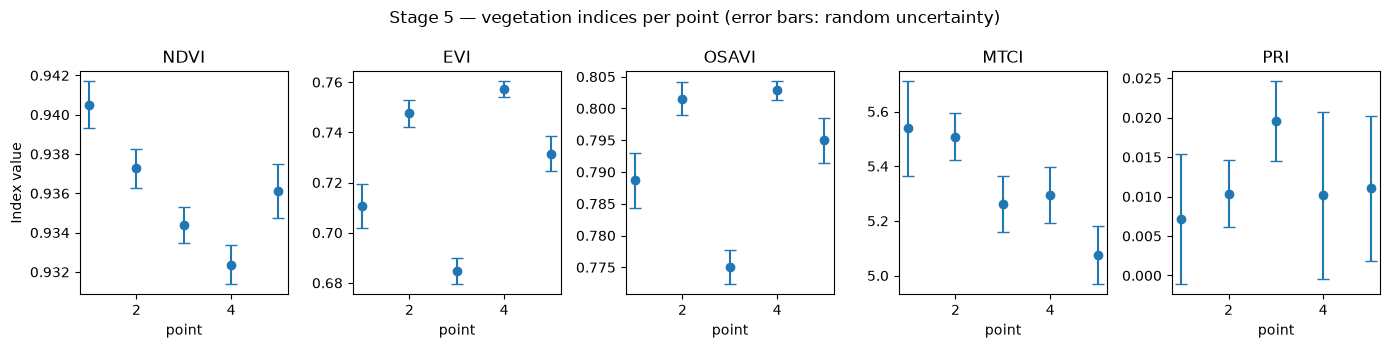

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(14, 3.5), sharex=True)
for ax, name in zip(axes, ['NDVI', 'EVI', 'OSAVI', 'MTCI', 'PRI']):
    ax.errorbar(range(1, 6), indices_df[name], yerr=indices_df[f'{name}_u_r'], fmt='o', capsize=4)
    ax.set_title(name); ax.set_xlabel('point')
axes[0].set_ylabel('Index value')
plt.suptitle('Stage 5 — vegetation indices per point (error bars: random uncertainty)')
plt.tight_layout(); plt.show()

## Result and validation

The reflectance value, plot-mean combined uncertainty, and all five
vegetation indices computed above match the official 2025 campaign output
for this plot to within floating-point precision — this notebook reproduces
the real pipeline end to end, not an approximation of it.

In [10]:
official_R = pd.read_csv(f"{DATA_DIR}/../case1b-plot103/official_plot_mean_reflectance.csv") if (DATA_DIR / "../case1b-plot103/official_plot_mean_reflectance.csv").exists() else None
print(indices_df[['point', 'NDVI', 'EVI', 'OSAVI', 'MTCI', 'PRI']])
print(f"\nPlot-mean reflectance at {wvlL[mR][0]:.0f}nm: {Rm[mR][0]:.6f} ± {ucRm[mR][0]:.6f} (combined, 1σ)")

   point      NDVI       EVI     OSAVI      MTCI       PRI
0  103p1  0.940506  0.710648  0.788711  5.538468  0.007140
1  103p2  0.937279  0.747541  0.801502  5.508227  0.010378
2  103p3  0.934399  0.684713  0.775041  5.262694  0.019541
3  103p4  0.932366  0.757170  0.802833  5.296153  0.010173
4  103p5  0.936104  0.731521  0.794959  5.073973  0.011041

Plot-mean reflectance at 400nm: 0.009256 ± 0.002475 (combined, 1σ)
